# Baseline: Feature Engineering Comparison (v0 vs v1)

## 0. Setup

In [1]:
import sys
sys.path.append("../..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml

from src.config import TRAIN_CSV, TEST_CSV, SAMPLE_SUBMIT_CSV, SEED, N_FOLDS, TARGET_COL, ID_COL
from src.utils import seed_everything
from src.features import compute_train_stats, build_pipeline
from src.evaluation import cross_validate, calc_metrics
from src.features import build_pipeline, get_feature_columns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
seed_everything(SEED)

with open("../../configs/default.yaml") as f:
    config = yaml.safe_load(f)

print("Feature version:", config["feature_version"])

Feature version: v1


## 1. Data Loading

In [2]:
train = pd.read_csv(TRAIN_CSV, index_col=0)
test = pd.read_csv(TEST_CSV, index_col=0)

y = train[TARGET_COL]
train = train.drop(columns=[TARGET_COL])

train_stats = compute_train_stats(train)
print("Train stats:", train_stats)

Train stats: {'age_median_by_pclass': {1: 36.0, 2: 29.0, 3: 25.0}, 'fare_median_by_pclass': {1: 69.3, 2: 15.0458, 3: 8.05}, 'embarked_mode': 'S', 'age_median_global': np.float64(28.0), 'fare_median_global': np.float64(15.0)}


## 2. Feature Engineering: v0 vs v1

In [3]:
X_v0 = build_pipeline(train, version="v0", train_stats=train_stats)
X_v1 = build_pipeline(train, version="v1", train_stats=train_stats)

print(f"v0 features ({X_v0.shape[1]}): {list(X_v0.columns)}")
print(f"v1 features ({X_v1.shape[1]}): {list(X_v1.columns)}")

v0 features (9): ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked_C', 'embarked_Q', 'embarked_S']
v1 features (14): ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked_C', 'embarked_Q', 'embarked_S', 'family_size', 'is_alone', 'log_fare', 'fare_per_person', 'pclass_sex']


### Feature Distributions (v1)

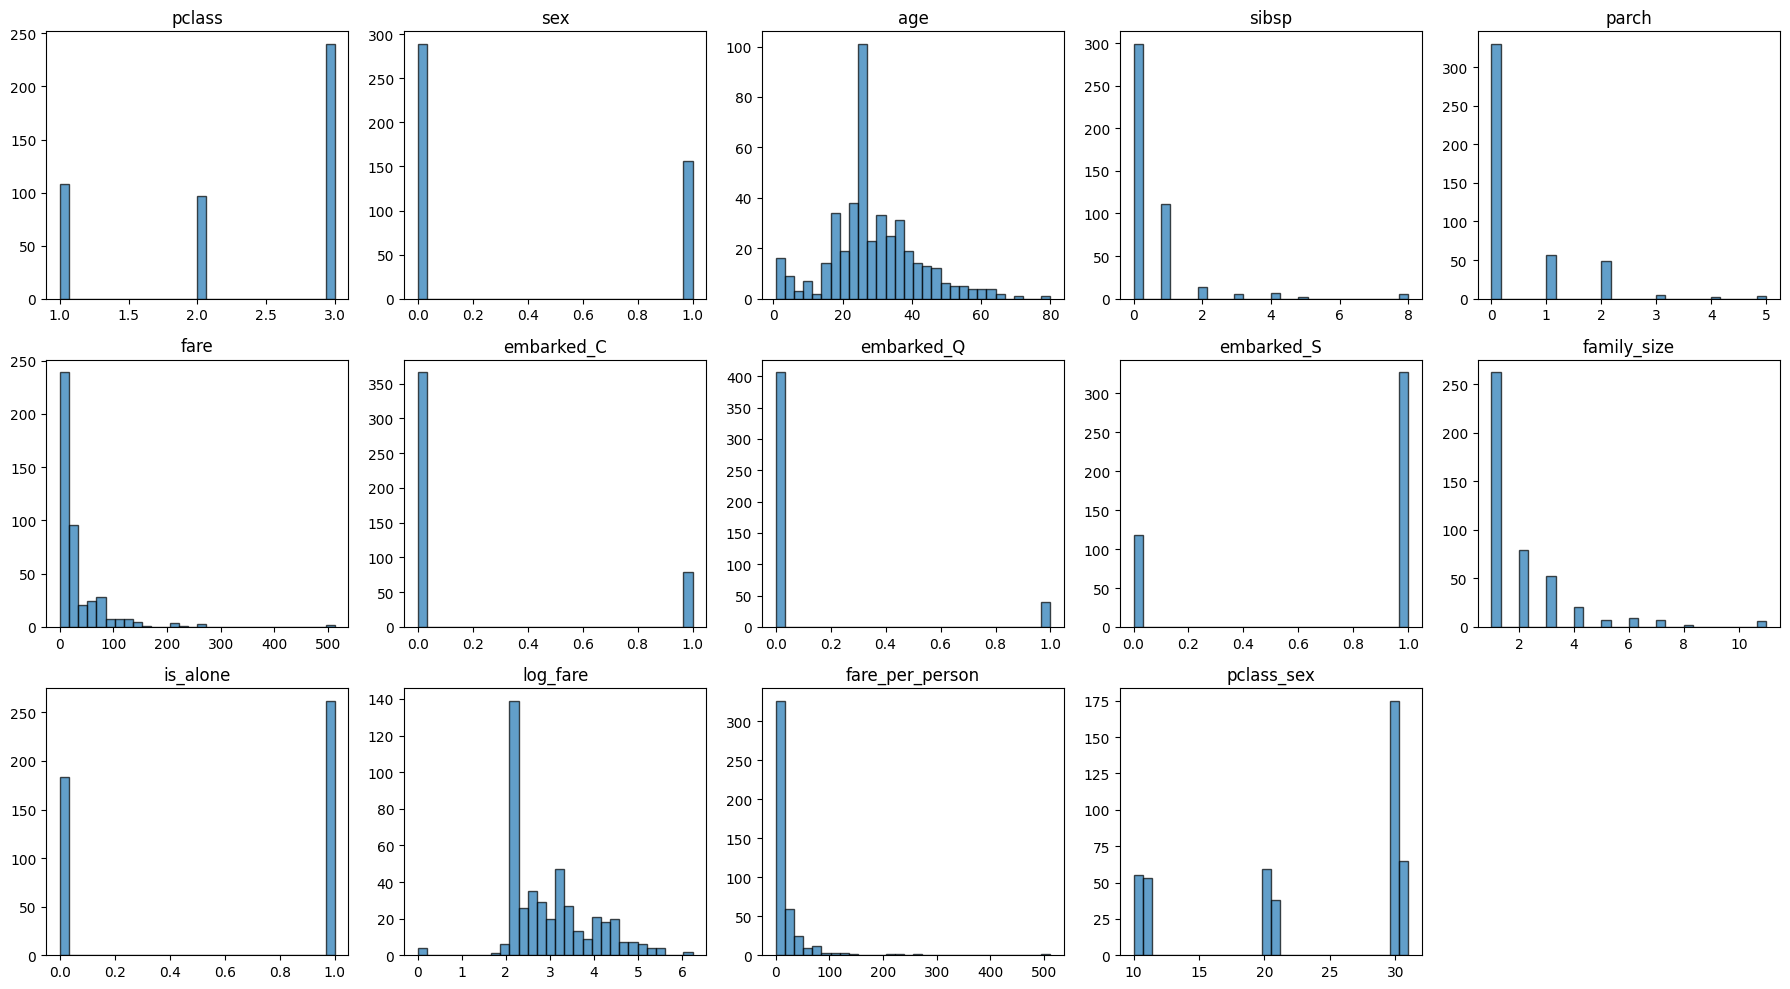

In [4]:
fig, axes = plt.subplots(3, 5, figsize=(18, 10))
axes = axes.ravel()
for i, col in enumerate(X_v1.columns):
    if i < len(axes):
        axes[i].hist(X_v1[col].dropna(), bins=30, edgecolor="black", alpha=0.7)
        axes[i].set_title(col)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

### Correlation Matrix (v1)

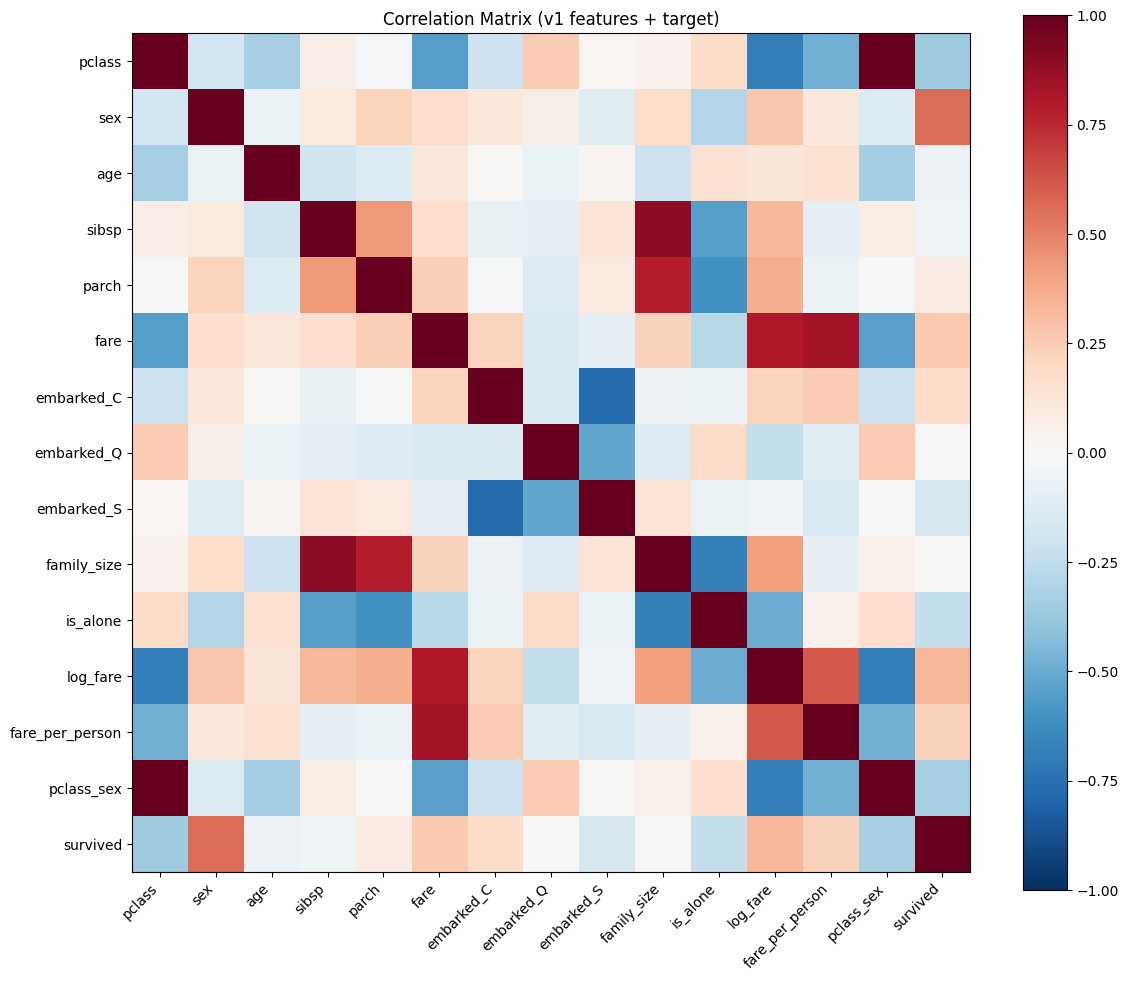

In [5]:
corr = pd.concat([X_v1, y], axis=1).corr()
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)
plt.colorbar(im)
plt.title("Correlation Matrix (v1 features + target)")
plt.tight_layout()
plt.show()

## 3. Cross-Validation Comparison

In [6]:
def model_fn():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            C=config["logistic_regression"]["C"],
            penalty=config["logistic_regression"]["penalty"],
            solver=config["logistic_regression"]["solver"],
            max_iter=config["logistic_regression"]["max_iter"],
            random_state=SEED,
        ))
    ])

print("=== v0 ===")
fold_metrics_v0, mean_metrics_v0 = cross_validate(model_fn, X_v0, y)
for k, v in mean_metrics_v0.items():
    print(f"  {k}: {v:.4f}")

print("\n=== v1 ===")
fold_metrics_v1, mean_metrics_v1 = cross_validate(model_fn, X_v1, y)
for k, v in mean_metrics_v1.items():
    print(f"  {k}: {v:.4f}")

=== v0 ===
  accuracy: 0.7955
  f1: 0.7344
  logloss: 0.4606
  auc: 0.8531

=== v1 ===
  accuracy: 0.8000
  f1: 0.7410
  logloss: 0.4566
  auc: 0.8536


/home/ryu/workspace/signate/signate-taitanic/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/ryu/workspace/signate/signate-taitanic/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/ryu/workspace/signate/signate-taitanic/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarnin

In [7]:
comparison = pd.DataFrame({
    "v0": mean_metrics_v0,
    "v1": mean_metrics_v1,
}).T
print("=== Comparison ===")
display(comparison)

improvement = mean_metrics_v1["accuracy"] - mean_metrics_v0["accuracy"]
print(f"\nAccuracy improvement (v1 - v0): {improvement:+.4f}")
if "auc" in mean_metrics_v1:
    auc_improvement = mean_metrics_v1["auc"] - mean_metrics_v0["auc"]
    print(f"AUC improvement (v1 - v0): {auc_improvement:+.4f}")

=== Comparison ===


,accuracy,f1,logloss,auc
v0,0.795506,0.734392,0.460589,0.853138
v1,0.800000,0.741026,0.456558,0.853625



Accuracy improvement (v1 - v0): +0.0045
AUC improvement (v1 - v0): +0.0005


## 4. Analysis

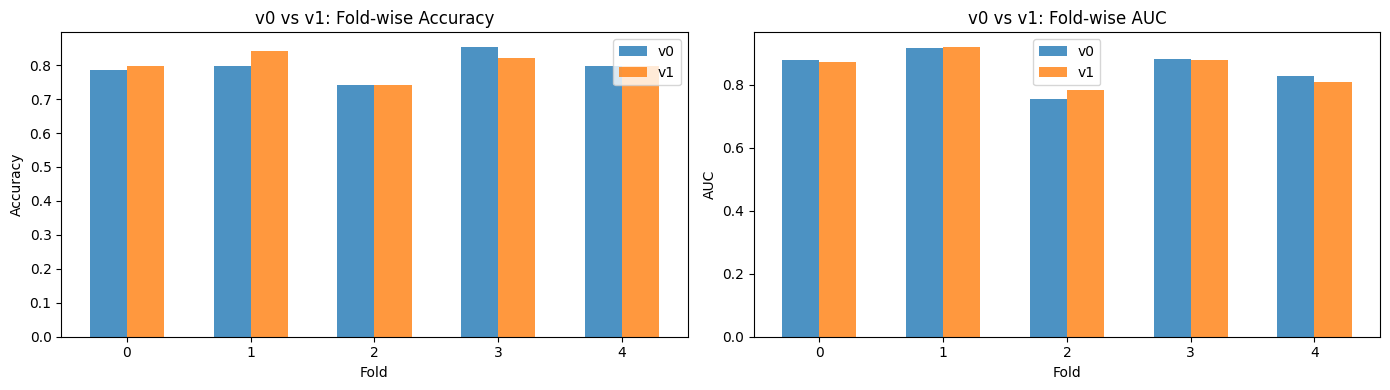

In [8]:
# Fold-level accuracy comparison
df_v0 = pd.DataFrame(fold_metrics_v0)
df_v1 = pd.DataFrame(fold_metrics_v1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

x = range(N_FOLDS)
axes[0].bar([i - 0.15 for i in x], df_v0["accuracy"], width=0.3, label="v0", alpha=0.8)
axes[0].bar([i + 0.15 for i in x], df_v1["accuracy"], width=0.3, label="v1", alpha=0.8)
axes[0].set_xlabel("Fold")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("v0 vs v1: Fold-wise Accuracy")
axes[0].legend()
axes[0].set_xticks(x)

axes[1].bar([i - 0.15 for i in x], df_v0["auc"], width=0.3, label="v0", alpha=0.8)
axes[1].bar([i + 0.15 for i in x], df_v1["auc"], width=0.3, label="v1", alpha=0.8)
axes[1].set_xlabel("Fold")
axes[1].set_ylabel("AUC")
axes[1].set_title("v0 vs v1: Fold-wise AUC")
axes[1].legend()
axes[1].set_xticks(x)

plt.tight_layout()
plt.show()